In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [2]:
dai = pd.read_parquet("./clean_data/dai_final.parquet")
pax = pd.read_parquet("./clean_data/pax_final.parquet")
usdc = pd.read_parquet("./clean_data/usdc_final.parquet")
usdt = pd.read_parquet("./clean_data/usdt_final.parquet")
ust = pd.read_parquet("./clean_data/ust_final.parquet")

In [3]:
dfs = {
    'DAI': dai,
    'UST': ust,
    'PAX': pax,
    'USDT': usdt,
    'USDC': usdc
}

cutoff = pd.Timestamp("2021-11-30")

summary = []

for name, df in dfs.items():
    train = df[df['timestamp'] <= cutoff]
    test = df[df['timestamp'] > cutoff]
    
    summary.append({
        'symbol': name,
        'train_start': train['timestamp'].min(),
        'train_end': train['timestamp'].max(),
        'test_start': test['timestamp'].min(),
        'test_end': test['timestamp'].max(),
        'train_depegs': train['depeg'].sum(),
        'test_depegs': test['depeg'].sum()
    })

summary_df = pd.DataFrame(summary)
summary_df

,symbol,train_start,train_end,test_start,test_end,train_depegs,test_depegs
0,DAI,2020-12-25 23:59:59,2021-11-29 23:59:59,2021-11-30 23:59:59,2026-03-19 23:59:59,16,7
1,UST,2020-12-25 23:59:59,2021-11-29 23:59:59,2021-11-30 23:59:59,2022-05-10 23:59:59,27,6
2,PAX,2020-12-25 23:59:59,2021-11-29 23:59:59,2021-11-30 23:59:59,2026-03-19 23:59:59,4,31
3,USDT,2020-12-25 23:59:59,2021-11-29 23:59:59,2021-11-30 23:59:59,2026-03-19 23:59:59,10,18
4,USDC,2020-12-25 23:59:59,2021-11-29 23:59:59,2021-11-30 23:59:59,2026-03-19 23:59:59,21,11


## Step 1: Split Data

In [4]:
## Combine all 5 stablecoin data

df_all = pd.concat([dai, pax, usdc, usdt, ust]).sort_values('timestamp').drop(columns = ["Unnamed: 0"])
df_all

,symbol,depeg,depeg_future_1d,depeg_future_3d,depeg_future_5d,depeg_future_7d,depeg_future_14d,depeg_future_30d,timestamp,timeOpen,...,realized_daily_volatility,peg_error,abs_peg_error,price_deviation_5d,price_deviation_30d,downward_price_deviation_5d,downward_price_deviation_30d,fear_greed_index,fear_greed_index_category,fed_funds_rate
0,DAI,0,0,0,0,0,0,1,2020-12-25 23:59:59,2020-12-25,...,0.002150,0.003095,0.003095,0.002241,0.003375,0.000000,0.000000,94.0,Extreme Greed,0.09
0,USDC,0,0,0,0,0,0,0,2020-12-25 23:59:59,2020-12-25,...,0.000533,0.000190,0.000190,0.000113,0.000235,0.000067,0.000060,94.0,Extreme Greed,0.09
0,USDT,0,0,0,0,0,0,0,2020-12-25 23:59:59,2020-12-25,...,0.000853,0.000168,0.000168,0.000323,0.000726,0.000314,0.000157,94.0,Extreme Greed,0.09
0,UST,0,0,0,0,0,0,0,2020-12-25 23:59:59,2020-12-25,...,0.004778,-0.001375,0.001375,0.002765,0.001560,0.002765,0.001541,94.0,Extreme Greed,0.09
0,USDP,0,0,0,0,0,0,0,2020-12-25 23:59:59,2020-12-25,...,0.006456,-0.000431,0.000431,0.000699,0.001598,0.000517,0.000691,94.0,Extreme Greed,0.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1909,USDC,0,0,0,0,0,0,0,2026-03-18 23:59:59,2026-03-18,...,0.000807,-0.000131,0.000131,0.000115,0.000098,0.000115,0.000083,26.0,Fear,3.64
1910,USDT,0,0,0,0,0,0,0,2026-03-19 23:59:59,2026-03-19,...,0.000657,0.000068,0.000068,0.000090,0.000198,0.000027,0.000177,23.0,Extreme Fear,NaN
1910,USDP,0,0,0,0,0,0,0,2026-03-19 23:59:59,2026-03-19,...,0.000365,-0.000793,0.000793,0.000574,0.000548,0.000574,0.000546,23.0,Extreme Fear,NaN
1910,DAI,0,0,0,0,0,0,0,2026-03-19 23:59:59,2026-03-19,...,0.000372,0.000044,0.000044,0.000088,0.000103,0.000086,0.000098,23.0,Extreme Fear,NaN


In [5]:
def prepare_stablecoin_pca_df(df):

    drop_cols = [
        'timeOpen', 'timeClose', 'timeHigh', 'timeLow',
        'open', 'high', 'low', 'close', 'volume', 'marketCap', 'circulatingSupply',
        'depeg_future_1d', 'depeg_future_3d', 'depeg_future_5d', 'depeg_future_7d', 
        'depeg_future_14d', 'depeg_future_30d'
    ]

    pca_df = df.copy()

    # Drop only columns that actually exist
    pca_df = pca_df.drop(columns=[c for c in drop_cols if c in pca_df.columns], errors="ignore")
    
    pca_df['timestamp'] = pd.to_datetime(pca_df['timestamp']).dt.normalize()
    # Keep only timestamp, symbol and numeric feature columns
    pca_df = pca_df[['timestamp', 'symbol'] + [c for c in pca_df.columns if c not in ['timestamp', 'symbol'] and pd.api.types.is_numeric_dtype(pca_df[c])]]

    # Sort by time
    pca_df = pca_df.sort_values('timestamp').reset_index(drop=True)
    
    return pca_df

df_all = prepare_stablecoin_pca_df(df_all)
df_all

,timestamp,symbol,depeg,percent_change_24h,percent_change_7d,percent_change_30d,volume_percent_change_24h,volume_percent_change_7d,volume_percent_change_30d,market_cap_percent_change_24h,...,circulating_supply_percent_change_30d,realized_daily_volatility,peg_error,abs_peg_error,price_deviation_5d,price_deviation_30d,downward_price_deviation_5d,downward_price_deviation_30d,fear_greed_index,fed_funds_rate
0,2020-12-25,DAI,0,0.030228,0.099151,0.185328,-22.779930,-13.206385,10.159630,-0.000287,...,-0.066435,0.002150,0.003095,0.003095,0.002241,0.003375,0.000000,0.000000,94.0,0.09
1,2020-12-25,USDC,0,0.011595,0.029346,0.013744,-6.591306,-3.274763,12.220217,0.000561,...,-0.208225,0.000533,0.000190,0.000190,0.000113,0.000235,0.000067,0.000060,94.0,0.09
2,2020-12-25,USDT,0,0.023632,-0.069940,0.011469,-1.864000,1.184042,-20.152195,-0.007563,...,-0.103282,0.000853,0.000168,0.000168,0.000323,0.000726,0.000314,0.000157,94.0,0.09
3,2020-12-25,UST,0,0.291308,0.052042,-0.094762,-21.996608,9.345063,166.910216,-0.003025,...,-2.506935,0.004778,-0.001375,0.001375,0.002765,0.001560,0.002765,0.001541,94.0,0.09
4,2020-12-25,USDP,0,-0.134788,0.035478,0.231384,9.495626,8.097903,-27.496875,0.001349,...,0.000000,0.006456,-0.000431,0.000431,0.000699,0.001598,0.000517,0.000691,94.0,0.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8141,2026-03-18,USDP,0,-0.006180,-0.011853,0.067650,-14.495465,24.460710,-55.363660,0.000062,...,0.159175,0.000398,-0.000543,0.000543,0.000510,0.000556,0.000510,0.000554,26.0,3.64
8142,2026-03-19,USDP,0,-0.024967,-0.013774,0.015779,181.485901,74.866909,13.974114,0.000250,...,0.159175,0.000365,-0.000793,0.000793,0.000574,0.000548,0.000574,0.000546,23.0,NaN
8143,2026-03-19,DAI,0,0.015746,0.008838,0.020364,-2.283090,4.809235,144.738547,-0.000153,...,0.000000,0.000372,0.000044,0.000044,0.000088,0.000103,0.000086,0.000098,23.0,NaN
8144,2026-03-19,USDT,0,0.012886,0.001769,0.055405,-4.891800,12.024595,21.859770,-0.000618,...,-0.002345,0.000657,0.000068,0.000068,0.000090,0.000198,0.000027,0.000177,23.0,NaN


In [6]:
## From above, 2021-11-30 seems like a good split to achieve approximately equal and balanced depegs in the train and test set

split_date = "2021-11-30" ## TUNE ACCORDINGLY

train = df_all[df_all['timestamp'] <= split_date].copy()
test  = df_all[df_all['timestamp'] > split_date].copy()

## Step 2: Standardization

In [7]:
numeric_cols = [c for c in train.columns if c not in ["depeg", "timestamp", "symbol"]]

imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(train[numeric_cols])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

X_test_imputed = imputer.transform(test[numeric_cols])
X_test_scaled = scaler.transform(X_test_imputed)

X_train_scaled

array([[ 0.04656794,  0.14139642,  0.24872086, ..., -0.27275705,
         1.44249628,  0.85136317],
       [ 0.01545768,  0.03702718,  0.01123148, ..., -0.25718946,
         1.44249628,  0.85136317],
       [ 0.03555475, -0.111422  ,  0.00808281, ..., -0.23177708,
         1.44249628,  0.85136317],
       ...,
       [ 1.37250235,  1.32462465,  1.02446094, ..., -0.27275705,
        -0.72124814, -0.67259925],
       [-0.74967886, -1.09221056,  0.03529909, ...,  0.37256704,
        -0.72124814, -0.67259925],
       [-0.10767952, -0.10538581, -0.04488371, ..., -0.21253895,
        -0.72124814, -0.67259925]], shape=(1705, 21))

In [8]:
X_test_scaled

array([[ 0.01899721, -0.17320991, -0.04486285, ..., -0.20984817,
        -0.96166419,  0.08938196],
       [-1.01223699,  0.47711736,  0.2512526 , ..., -0.27275705,
        -0.96166419,  0.08938196],
       [-0.00897338, -0.07286473, -0.01277749, ..., -0.25370738,
        -0.96166419,  0.08938196],
       ...,
       [ 0.0223888 ,  0.00636457,  0.02039406, ..., -0.24722959,
        -1.40242694,  0.        ],
       [ 0.01761303, -0.00420542,  0.06889363, ..., -0.22649534,
        -1.40242694,  0.        ],
       [ 0.02319536,  0.01424452,  0.00703305, ..., -0.2514312 ,
        -1.40242694,  0.        ]], shape=(6441, 21))

## Step 3: PCA Training

In [9]:
n_components = 10

pca = PCA(n_components)
X_train_pca = pca.fit_transform(X_train_scaled)

pca_result = {
    "pca": pca,
    "pc_scores_train": pd.DataFrame(X_train_pca, index=train.index),
    "explained_variance": pca.explained_variance_ratio_
}

print(pca_result["explained_variance"])

[0.21169564 0.16024479 0.11679838 0.07449475 0.06785043 0.05411952
 0.04824563 0.04614154 0.04354664 0.04097437]


In [10]:
pca_result["pc_scores_train"]

,0,1,2,3,4,5,6,7,8,9
0,0.596727,-0.143111,0.440093,-0.241471,-0.042605,-1.131472,-0.872904,-0.209079,0.651193,1.150415
1,0.246003,0.327964,-0.421023,0.238573,0.549856,-0.379677,-0.871854,-0.553140,1.031267,0.712116
2,0.553567,0.061506,-0.353484,0.139193,-0.095792,-0.284186,-0.744770,-0.547000,0.891807,1.041443
3,-5.973919,1.584009,0.444087,-0.222124,4.824941,0.676784,-0.915638,-1.003131,1.245989,1.953959
4,0.860690,-0.358620,0.165552,0.355502,-0.265750,-0.353708,-0.610878,-0.399980,0.842412,1.048813
...,...,...,...,...,...,...,...,...,...,...
1700,0.787731,-0.449032,0.567673,1.427782,-0.775657,1.975386,0.406520,-0.221342,-0.936252,-0.512940
1701,1.026713,-0.266778,-0.111300,-0.132501,-0.112967,0.531273,0.370694,0.230258,-0.651515,-0.297671
1702,-2.389101,2.086561,2.178336,0.644918,0.861813,0.629622,-0.144962,0.138338,-1.605930,-0.579163
1703,0.500536,-1.149515,0.223727,0.485728,-0.486334,0.612262,0.923012,0.172300,-0.599014,-0.334149


## Step 4: Select PCs to Monitor

In [11]:
selected_pcs = [0, 2, 9] ## Selecr PC1, 3, 10 , CAN TUNE ACCORDINGLY 
pc_cols = [f"PC{i+1}" for i in selected_pcs]

## Step 5: Benchmark Training

In [12]:
def compute_training_benchmark_pooled(X_train_pca, selected_pcs):
    pc_scores = pd.DataFrame(X_train_pca[:, selected_pcs],
                             columns = pc_cols)

    mu = pc_scores.mean()
    sigma = pc_scores.std()

    return {
        "mu": mu,
        "sigma": sigma,
        "pc_cols": pc_scores.columns.tolist()
    }

benchmark = compute_training_benchmark_pooled(X_train_pca, selected_pcs)

## Step 6: Project Test Data

In [13]:
X_test_pca = pca.transform(X_test_scaled)

pc_scores_test = pd.DataFrame(
    X_test_pca[:, selected_pcs],
    columns=benchmark["pc_cols"],
    index=test.index
)

pc_scores_test

,PC1,PC3,PC10
1705,0.580209,-0.484057,-0.735147
1706,-2.133809,0.356789,-0.474711
1707,1.134659,-0.253258,-0.538353
1708,0.469883,-0.123371,-0.508894
1709,1.203579,-0.018351,-0.556245
...,...,...,...
8141,20.070580,18.035852,-42.014983
8142,1.183762,0.887607,-1.380531
8143,1.319477,0.113438,-0.834434
8144,1.425418,-0.044239,-0.835894


## Step 7: Z-Scores

In [14]:
def compute_test_zscores_pooled(pc_scores_test, benchmark):
    z_scores = (pc_scores_test - benchmark["mu"]) / benchmark["sigma"]
    z_scores.columns = [f"z_{c}" for c in benchmark["pc_cols"]]
    return z_scores

z_scores = compute_test_zscores_pooled(pc_scores_test, benchmark)
z_scores

,z_PC1,z_PC3,z_PC10
1705,0.275101,-0.308988,-0.792284
1706,-1.011725,0.227749,-0.511606
1707,0.537988,-0.161662,-0.580195
1708,0.222791,-0.078752,-0.548447
1709,0.570666,-0.011714,-0.599478
...,...,...,...
8141,9.516274,11.512807,-45.280477
8142,0.561270,0.566585,-1.487829
8143,0.625617,0.072411,-0.899288
8144,0.675849,-0.028239,-0.900862


## Step 8: Signal

In [15]:
def generate_signal(z_scores, threshold=3.0, consecutive_days=1):
    """
    Binary signal: 1 if ANY monitored PC exceeds ±threshold.
    consecutive_days > 1 requires that many consecutive triggers (noise filter).
    """
    any_exceed = (z_scores.abs() > threshold).any(axis=1).astype(int)
    if consecutive_days <= 1:
        return any_exceed
    rolling_sum = any_exceed.rolling(window=consecutive_days, min_periods=consecutive_days).sum()
    return (rolling_sum >= consecutive_days).astype(int)

signal = generate_signal(z_scores, threshold=3.0, consecutive_days=1)
signal

1705    0
1706    0
1707    0
1708    0
1709    0
       ..
8141    1
8142    0
8143    0
8144    0
8145    0
Length: 6441, dtype: int64

## Step 9: Build Labels

In [16]:
def build_warning_labels(test_df, signal, window_days=7,
                         date_col="timestamp", depeg_col="depeg"):
    """
    Label each test day 1 if it falls within `window_days` before a depeg
    (inclusive of the depeg day itself). Also records lead_days to next depeg.
    """
    df = test_df[[date_col, depeg_col]].copy().reset_index(drop=True)
    df["date"]   = pd.to_datetime(df[date_col]).dt.normalize()
    df["signal"] = signal.values
    df["depeg"]  = df[depeg_col].values

    depeg_dates = df.loc[df["depeg"] == 1, "date"].values

    def min_lead(d):
        future = depeg_dates[depeg_dates >= d]
        return (future[0] - d) / np.timedelta64(1, "D") if len(future) > 0 else np.nan

    df["lead_days"] = df["date"].apply(min_lead)
    df["label"]     = ((df["lead_days"] >= 0) & (df["lead_days"] <= window_days)).astype(int)
    return df[["date", "signal", "depeg", "label", "lead_days"]]

test_results = test.copy()
test_results["signal"] = signal

results_per_coin = {}

for coin in test_results["symbol"].unique():
    df_coin = test_results[test_results["symbol"] == coin].copy()

    labeled_df = build_warning_labels(df_coin, df_coin["signal"], window_days=7)

    results_per_coin[coin] = labeled_df

results_per_coin

{'USDC':            date  signal  depeg  label  lead_days
 0    2021-12-01       0      0      1        1.0
 1    2021-12-02       0      1      1        0.0
 2    2021-12-03       0      0      1        2.0
 3    2021-12-04       0      0      1        1.0
 4    2021-12-05       0      1      1        0.0
 ...         ...     ...    ...    ...        ...
 1565 2026-03-15       1      0      0        NaN
 1566 2026-03-16       1      0      0        NaN
 1567 2026-03-17       1      0      0        NaN
 1568 2026-03-18       1      0      0        NaN
 1569 2026-03-19       0      0      0        NaN
 
 [1570 rows x 5 columns],
 'UST':           date  signal  depeg  label  lead_days
 0   2021-12-01       0      0      0       20.0
 1   2021-12-02       0      0      0       19.0
 2   2021-12-03       0      0      0       18.0
 3   2021-12-04       0      0      0       17.0
 4   2021-12-05       0      0      0       16.0
 ..         ...     ...    ...    ...        ...
 156 2022-05-0

## Stage 10: Compute Metrics

In [17]:
def compute_metrics(labeled_df, coin=""):
    """Precision (key), recall, F1, specificity, avg lead time, false alarms/month."""
    y_true = labeled_df["label"].values
    y_pred = labeled_df["signal"].values

    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())

    precision   = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall      = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1          = (2 * precision * recall / (precision + recall)
                   if not (np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0)
                   else np.nan)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan

    tp_mask      = (y_pred == 1) & (y_true == 1)
    avg_lead     = labeled_df.loc[tp_mask, "lead_days"].dropna().mean()
    fa_per_month = FP / (len(labeled_df) / 30.44)

    print(f"\n{'='*50}")
    print(f"  {coin} — Predictive Metrics")
    print(f"{'='*50}")
    print(f"  Confusion: TP={TP}, FP={FP}, TN={TN}, FN={FN}")
    print(f"  Precision  (key): {precision:.3f}")
    print(f"  Recall:           {recall:.3f}")
    print(f"  F1:               {f1:.3f}")
    print(f"  Specificity:      {specificity:.3f}")
    print(f"  Avg lead time:    {avg_lead:.1f} days before depeg")
    print(f"  False alarms:     {fa_per_month:.2f} / month")

    return {
        "coin": coin,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "specificity": round(specificity, 4),
        "avg_lead_days": round(avg_lead, 2) if not np.isnan(avg_lead) else np.nan,
        "fa_per_month": round(fa_per_month, 2),
        "n_test_days": len(labeled_df),
    }

metrics_list = []

for coin, labeled_df in results_per_coin.items():
    metrics = compute_metrics(labeled_df, coin=coin)
    metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list)
metrics_df


  USDC — Predictive Metrics
  Confusion: TP=18, FP=1441, TN=81, FN=30
  Precision  (key): 0.012
  Recall:           0.375
  F1:               0.024
  Specificity:      0.053
  Avg lead time:    2.7 days before depeg
  False alarms:     27.94 / month

  UST — Predictive Metrics
  Confusion: TP=9, FP=46, TN=89, FN=17
  Precision  (key): 0.164
  Recall:           0.346
  F1:               0.222
  Specificity:      0.659
  Avg lead time:    3.1 days before depeg
  False alarms:     8.70 / month

  USDT — Predictive Metrics
  Confusion: TP=67, FP=1396, TN=107, FN=0
  Precision  (key): 0.046
  Recall:           1.000
  F1:               0.088
  Specificity:      0.071
  Avg lead time:    2.9 days before depeg
  False alarms:     27.07 / month

  DAI — Predictive Metrics
  Confusion: TP=16, FP=1448, TN=88, FN=18
  Precision  (key): 0.011
  Recall:           0.471
  F1:               0.021
  Specificity:      0.057
  Avg lead time:    2.5 days before depeg
  False alarms:     28.07 / month

 

,coin,TP,FP,TN,FN,precision,recall,f1,specificity,avg_lead_days,fa_per_month,n_test_days
0,USDC,18,1441,81,30,0.0123,0.3750,0.0239,0.0532,2.72,27.94,1570
1,UST,9,46,89,17,0.1636,0.3462,0.2222,0.6593,3.11,8.70,161
2,USDT,67,1396,107,0,0.0458,1.0000,0.0876,0.0712,2.93,27.07,1570
3,DAI,16,1448,88,18,0.0109,0.4706,0.0214,0.0573,2.50,28.07,1570
4,USDP,177,1283,110,0,0.1212,1.0000,0.2162,0.0790,3.05,24.88,1570


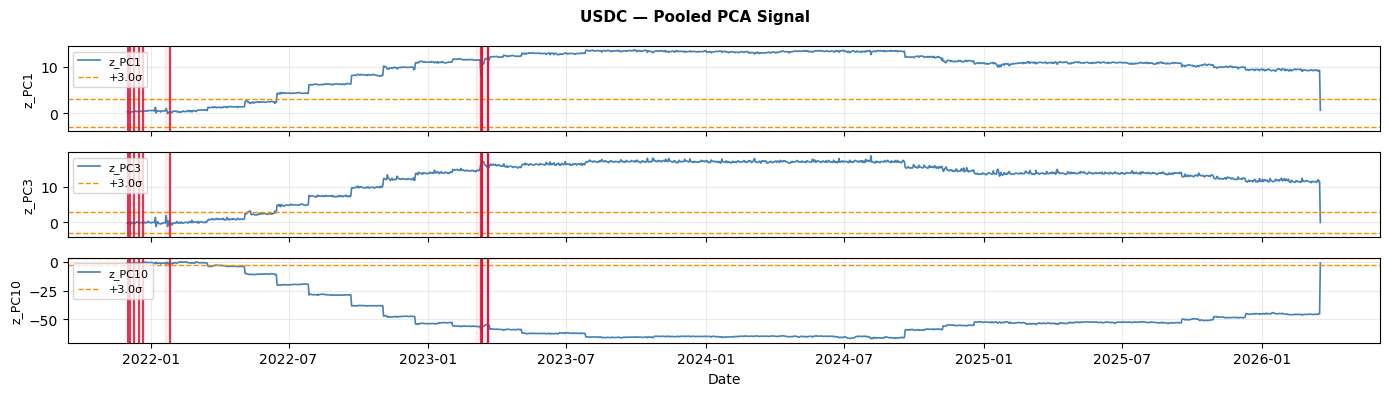

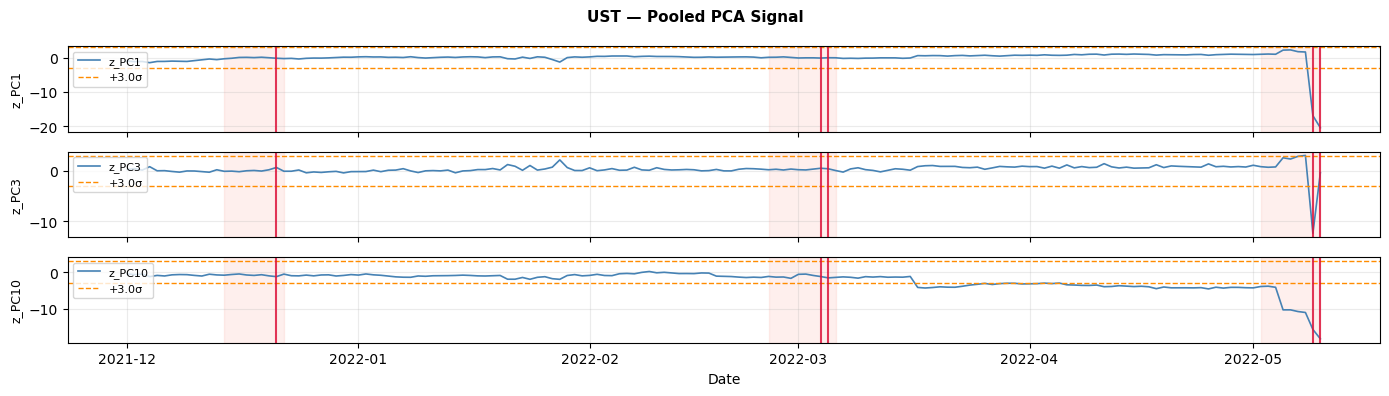

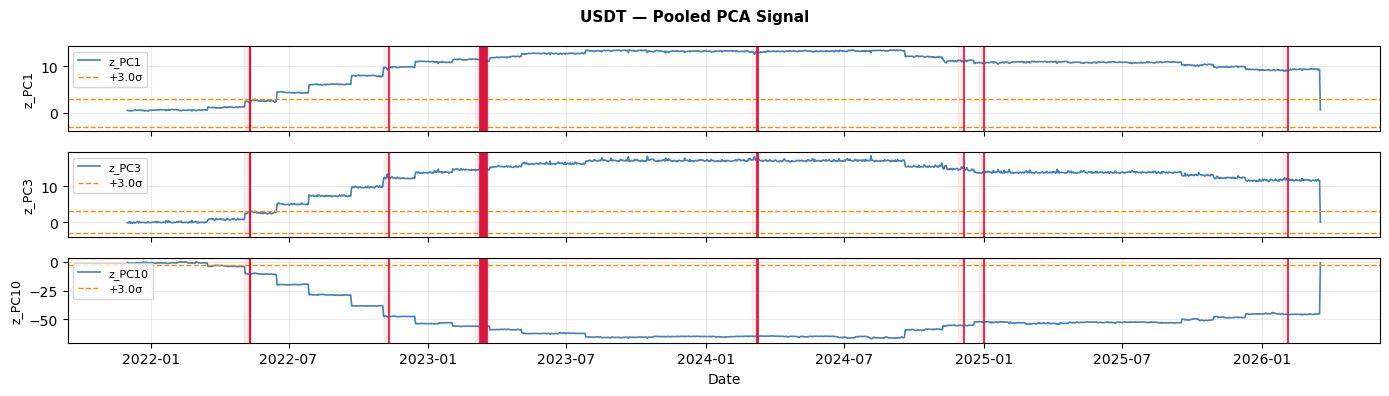

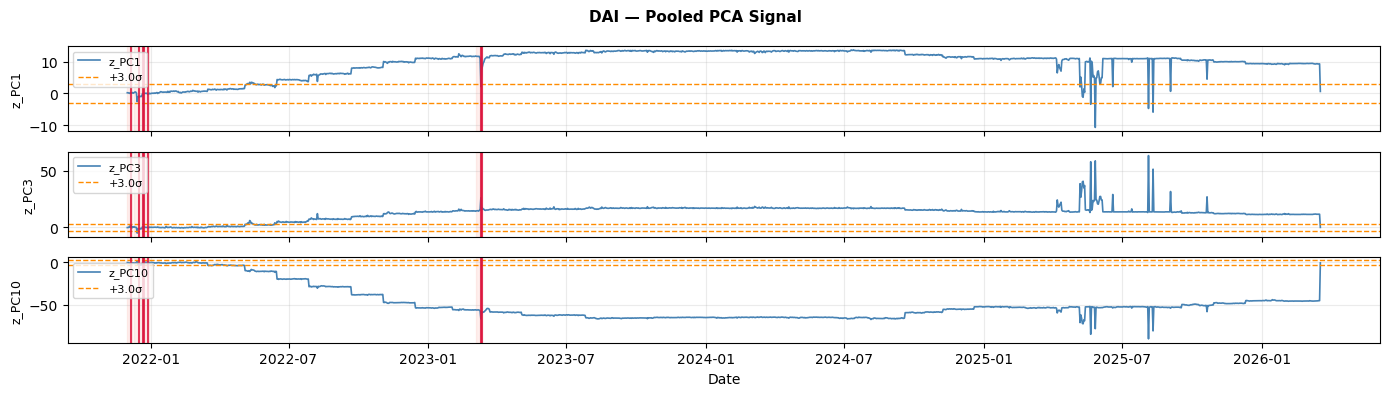

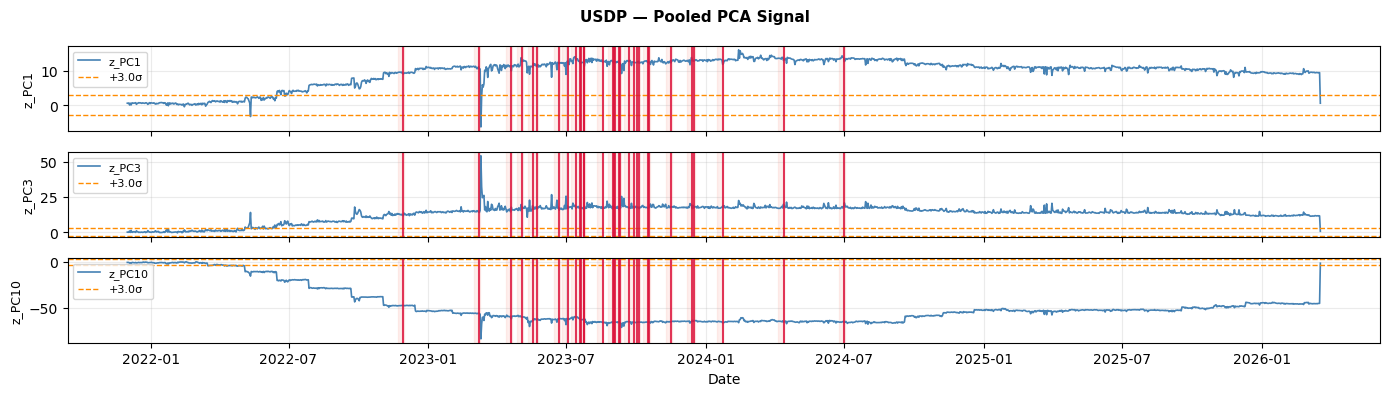

In [18]:
test["signal"] = signal
# z-scores for ALL observations
z_scores_full = z_scores.copy()
z_scores_full["symbol"] = test["symbol"].values
z_scores_full["timestamp"] = test["timestamp"].values

pooled_results = {}

for coin in test["symbol"].unique():
    df_coin = test[test["symbol"] == coin].copy()

    # Slice z-scores
    z_coin = z_scores_full[z_scores_full["symbol"] == coin].copy()
    z_coin = z_coin.drop(columns=["symbol", "timestamp"])

    # Build labels (same as before)
    labeled_df = build_warning_labels(
        df_coin,
        df_coin["signal"],
        window_days=7
    )

    pooled_results[coin] = {
        "z_scores": z_coin.reset_index(drop=True),
        "labeled_df": labeled_df.reset_index(drop=True)
    }

def plot_signal_timeline_pooled(result, coin, threshold=3.0, figsize=(14, 4)):
    labeled_df = result["labeled_df"]
    z_scores   = result["z_scores"]

    dates = labeled_df["date"].values

    fig, axes = plt.subplots(len(z_scores.columns), 1, figsize=figsize, sharex=True)

    if len(z_scores.columns) == 1:
        axes = [axes]

    for ax, col in zip(axes, z_scores.columns):
        ax.plot(dates, z_scores[col].values, lw=1.2, label=col, color = "steelblue")

        ax.axhline( threshold, color="darkorange", ls="--", lw=1, label=f"+{threshold}σ")
        ax.axhline(-threshold, color="darkorange", ls="--", lw=1)

        # Warning window shading
        in_window = labeled_df["label"].values == 1
        starts = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == 1)[0]
        ends   = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == -1)[0]

        for s, e in zip(starts, ends):
            ax.axvspan(dates[s], dates[min(e, len(dates)-1)], alpha=0.12, color = "salmon")

        # Depeg markers
        for dd in labeled_df.loc[labeled_df["depeg"] == 1, "date"].values:
            ax.axvline(dd, lw=1.5, alpha=0.85, color = "crimson")

        ax.set_ylabel(col, fontsize=9)
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel("Date")
    fig.suptitle(f"{coin} — Pooled PCA Signal", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.show()

for coin, res in pooled_results.items():
    plot_signal_timeline_pooled(res, coin=coin)